# Linear Regression with EPL Data

In this task, you will create a model for the number of points for EPL teams, based on their goals for, goals against and goal difference.

First let's load the latest Premier League table into a `pandas` dataframe.

In [2]:
# Import required libraries
import requests as r, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Create a header that says the request is coming form a browser-like agent (this is to prevent the website blocking our request)
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36',
}
# Make an http request to get the webpage with the following url
url = "http://bbc.co.uk/sport/football/premier-league/table"
page = r.get(url, headers = headers)
if(page.status_code!=200):
    print("Stopping - couldn't get web page.")
else:
    print("Web request status code:", page.status_code)
    # read_html() will find all the tables in the webpage and put them in a list.
    tables = pd.read_html(page.content)
    # In this case, there is only one table, so the length of the list should be 1.
    print("Tables found on webpage:", len(tables))
    EPL = tables[0]
    print("Preparing dataframe of EPL table")
    EPL.insert(loc=0, value=0, column='Position')
    EPL.drop(columns=['Form, Last 6 games, Oldest first'], inplace=True)
    EPL.insert(loc=1, value='', column='Team New')
    rows = EPL.shape[0]
    for x in range(rows):
        EPL.iloc[x, 0]=x+1
        raw_name = EPL.iloc[x, 2]
        if x < 9:
            EPL.iloc[x, 1] = raw_name[1:len(raw_name)]
        elif x >=9:
            EPL.iloc[x, 1] = raw_name[2:len(raw_name)]
    EPL.drop(columns=['Team'], inplace=True)
    EPL.rename(columns={"Team New":"Team"}, inplace=True)
    EPL.rename(columns={'Drawn':"Tied"}, inplace=True)

Web request status code: 200
Tables found on webpage: 1
Preparing dataframe of EPL table


In [3]:
# Take a look at the dataframe
EPL.head()

,Position,Team,Played,Won,Tied,Lost,Goals For,Goals Against,Goal Difference,Points
0,1,Arsenal,30,20,7,3,59,22,37,67
1,2,Manchester City,29,18,6,5,59,27,32,60
2,3,Manchester United,29,14,9,6,51,40,11,51
3,4,Aston Villa,29,15,6,8,39,34,5,51
4,5,Chelsea,29,13,9,7,53,34,19,48


## Goals For versus Goals Against

First we'll compare 'Goals For' and 'Goals Against'. We will treat 'Goals For' as the `x` values (independent variable) and 'Goals Against' as the  `y` values. 

The code below will be a model for you for the tasks that follow.

slope: -0.532
intercept: 61.804
r: -0.590


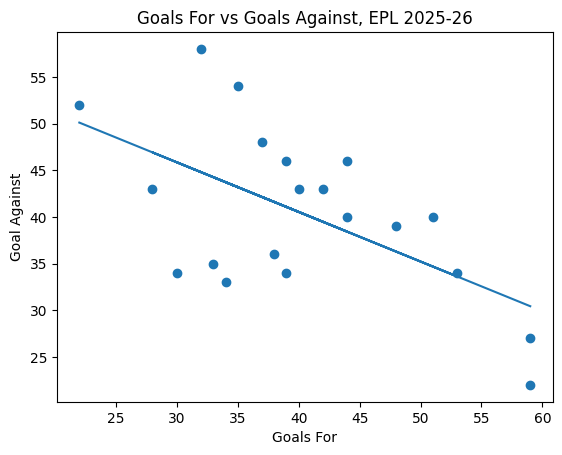

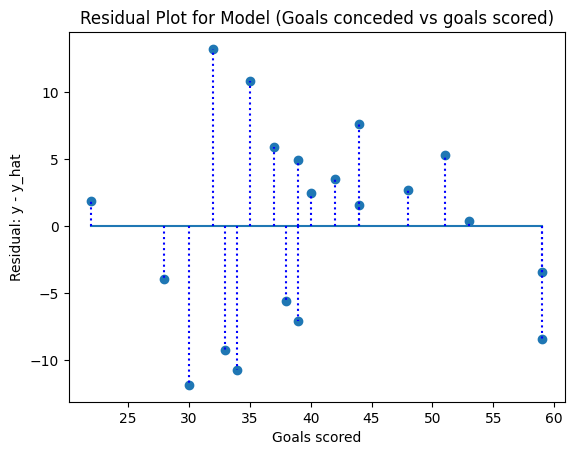

In [4]:
# Pick the relevant columns of the dataframe and convert to numpy arrays
x = np.array(EPL['Goals For'])
y = np.array(EPL['Goals Against'])

# Calculate regression parameters/statistics
m, b, r, p, std_err = stats.linregress(x, y)
print(f"slope: {m:.3f}")
print(f"intercept: {b:.3f}")
print(f"r: {r:.3f}")

# Plot scatter plot and line of best fit
y_hat = m*x+b
plt.plot(x, y_hat)
plt.title("Goals For vs Goals Against, EPL 2025-26")
plt.xlabel("Goals For")
plt.ylabel("Goal Against")
plt.scatter(x, y)
plt.show()

# Create residuals
residuals = y-y_hat

# Plot residuals
plt.scatter(x, residuals)
plt.plot([x.min(), x.max()], [0,0])
for i in range(len(residuals)):
    plt.plot([x[i], x[i]], [0, residuals[i]], ':b')
plt.title("Residual Plot for Model (Goals conceded vs goals scored)")
plt.xlabel("Goals scored")
plt.ylabel("Residual: y - y_hat")
plt.show()

## Your Task

We want to see which of the following is the best predictor of the total points a team has:
- Goals For
- Goals Against
- Goal Difference
  
Your task is to look at the following three different combinations of bivariate data from the table.
- Points (y) vs Goals For (x)
- Points (y) vs Goals Against (x)
- Points (y) vs Goal Difference (x)

For each of these pairs above, do the following:
- Create a scatter plot
- Calculate the correlation coefficient and the slope and intercept of the regression line
- Plot the line of best fit on the same graph as the scatter plot
- Create an array of residuals and plot them

Once you've done these tasks for each combination above, decide which of 'Goals For', Goals Against' and 'Goal Difference' is the best predictor for the number of points a team has.

### Task 1: Points vs Goals For

Put your code for this task in the cell below.

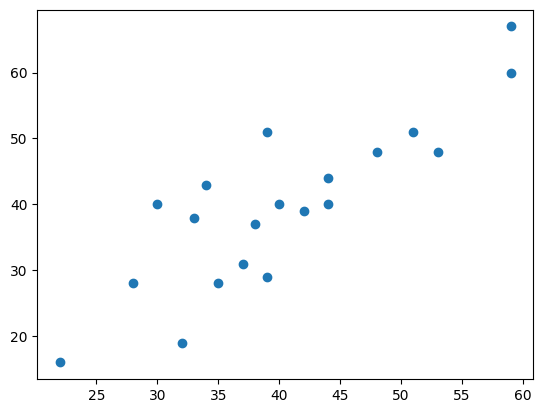

slope: 1.088
intercept: -4.034
r: 0.852


In [5]:
# Type your code here
x = EPL['Goals For']
y = EPL['Points']
plt.scatter(x, y)
plt.show()

slope, intercept, r, p, std_err = stats.linregress(x, y)
print(f"slope: {slope:.3f}")
print(f"intercept: {intercept:.3f}")
print(f"r: {r:.3f}")

In [ ]:
### Task 2: Points vs Goals Against

Type your code in the cell below.

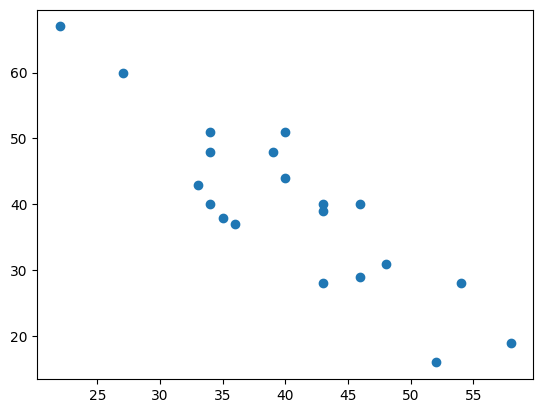

slope: -1.238
intercept: 89.789
r: -0.873


In [6]:
# Type your code here
x = EPL['Goals Against']
y = EPL['Points']
plt.scatter(x, y)
plt.show()

slope, intercept, r, p, std_err = stats.linregress(x, y)
print(f"slope: {slope:.3f}")
print(f"intercept: {intercept:.3f}")

print(f"r: {r:.3f}")

In [ ]:
### Task 3: Points vs Goal Difference

Type your code in the cell below.

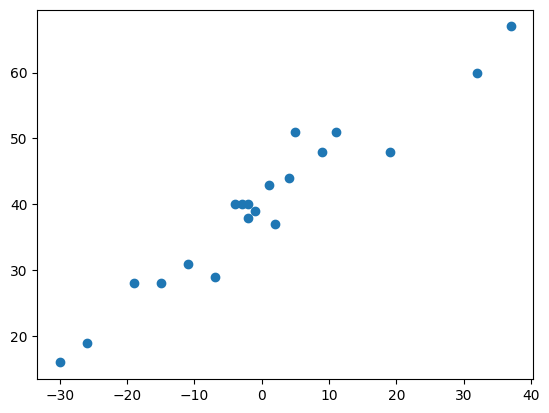

slope: 0.728
intercept: 39.850
r: 0.966


In [7]:
# Type your code here
x = EPL['Goal Difference']
y = EPL['Points']
plt.scatter(x, y)
plt.show()

slope, intercept, r, p, std_err = stats.linregress(x, y)
print(f"slope: {slope:.3f}")
print(f"intercept: {intercept:.3f}")

print(f"r: {r:.3f}")

## Conclusion

Which of these three models is the best? Justify your reasoning.